In [8]:
import numpy as np
import pandas as pd
df = pd.read_csv('placement.csv')


In [9]:
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [10]:
df.head()


,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [11]:
df.shape


(100, 4)

In [ ]:
#Steps
#1. Data Preprocessing + EDA + Feature Engineering
#2. Extract input and output features
# Scale the value
#2. Train Test Split
#3. Train the model
#4. Evaluation
#5. Deployment

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [13]:
df = df.iloc[:,1:]

In [14]:
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


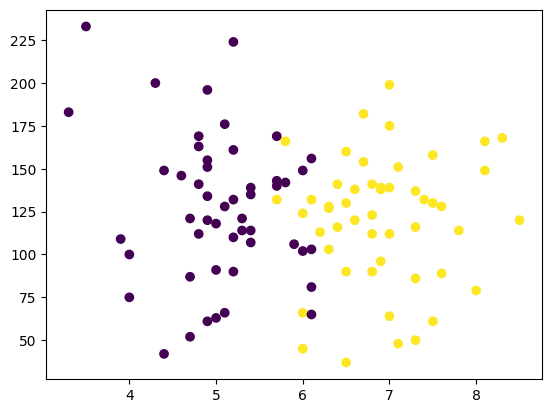

In [16]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [20]:

x = df.iloc[:,0:2]
y = df.iloc[:,-1]
y.shape

(100,)

In [21]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=40)

In [22]:
x_train

,cgpa,iq
86,5.1,128.0
4,5.8,142.0
47,5.2,161.0
27,6.0,124.0
81,5.4,107.0
...,...,...
56,6.1,65.0
37,8.1,149.0
7,5.0,63.0
91,7.5,158.0


In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [25]:
x_train

array([[-0.78524968,  0.12992785],
       [-0.18560447,  0.47750554],
       [-0.69958608,  0.94921812],
       [-0.01427727,  0.03061994],
       [-0.52825888, -0.39143868],
       [-2.32719452,  1.49541163],
       [ 0.41404074, -2.12932713],
       [-0.01427727,  0.65129439],
       [-0.78524968, -1.40934478],
       [-0.69958608, -0.31695775],
       [ 1.09934956, -0.16799588],
       [ 0.75669515, -0.66453544],
       [ 2.12731278, -0.06868797],
       [-0.87091329, -0.11834193],
       [ 0.84235875,  1.89264328],
       [-1.7275493 , -1.18590198],
       [ 1.09934956, -1.80657642],
       [-0.61392248, -0.04386099],
       [-0.95657689,  0.80025625],
       [-0.95657689,  1.81816234],
       [ 0.49970434, -0.06868797],
       [ 0.84235875,  0.40302461],
       [-1.04224049,  0.45267856],
       [ 0.67103155,  0.00579296],
       [ 0.32837714,  0.45267856],
       [-0.01427727, -1.93071131],
       [-0.27126807,  0.42785158],
       [ 0.92802235,  0.70094834],
       [ 0.49970434,

In [27]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [28]:
#model training
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [31]:
y_pred = model.predict(x_test)

In [30]:
y_test

79    1
75    0
63    1
15    0
38    1
11    1
40    0
45    1
39    0
62    0
Name: placement, dtype: int64

In [32]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9

In [39]:
#visualization
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x_train, y_train.values, clf=model)

ModuleNotFoundError: No module named 'mlxtend'

<Axes: >

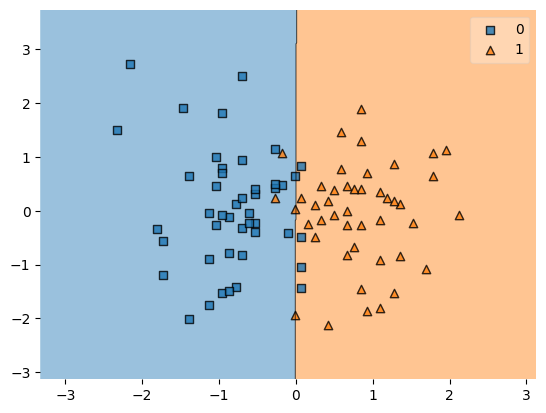

In [44]:
#visualization
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x_train, y_train.values, clf=model)

In [45]:
import pickle 
pickle.dump(model, open('model.pkl','wb'))